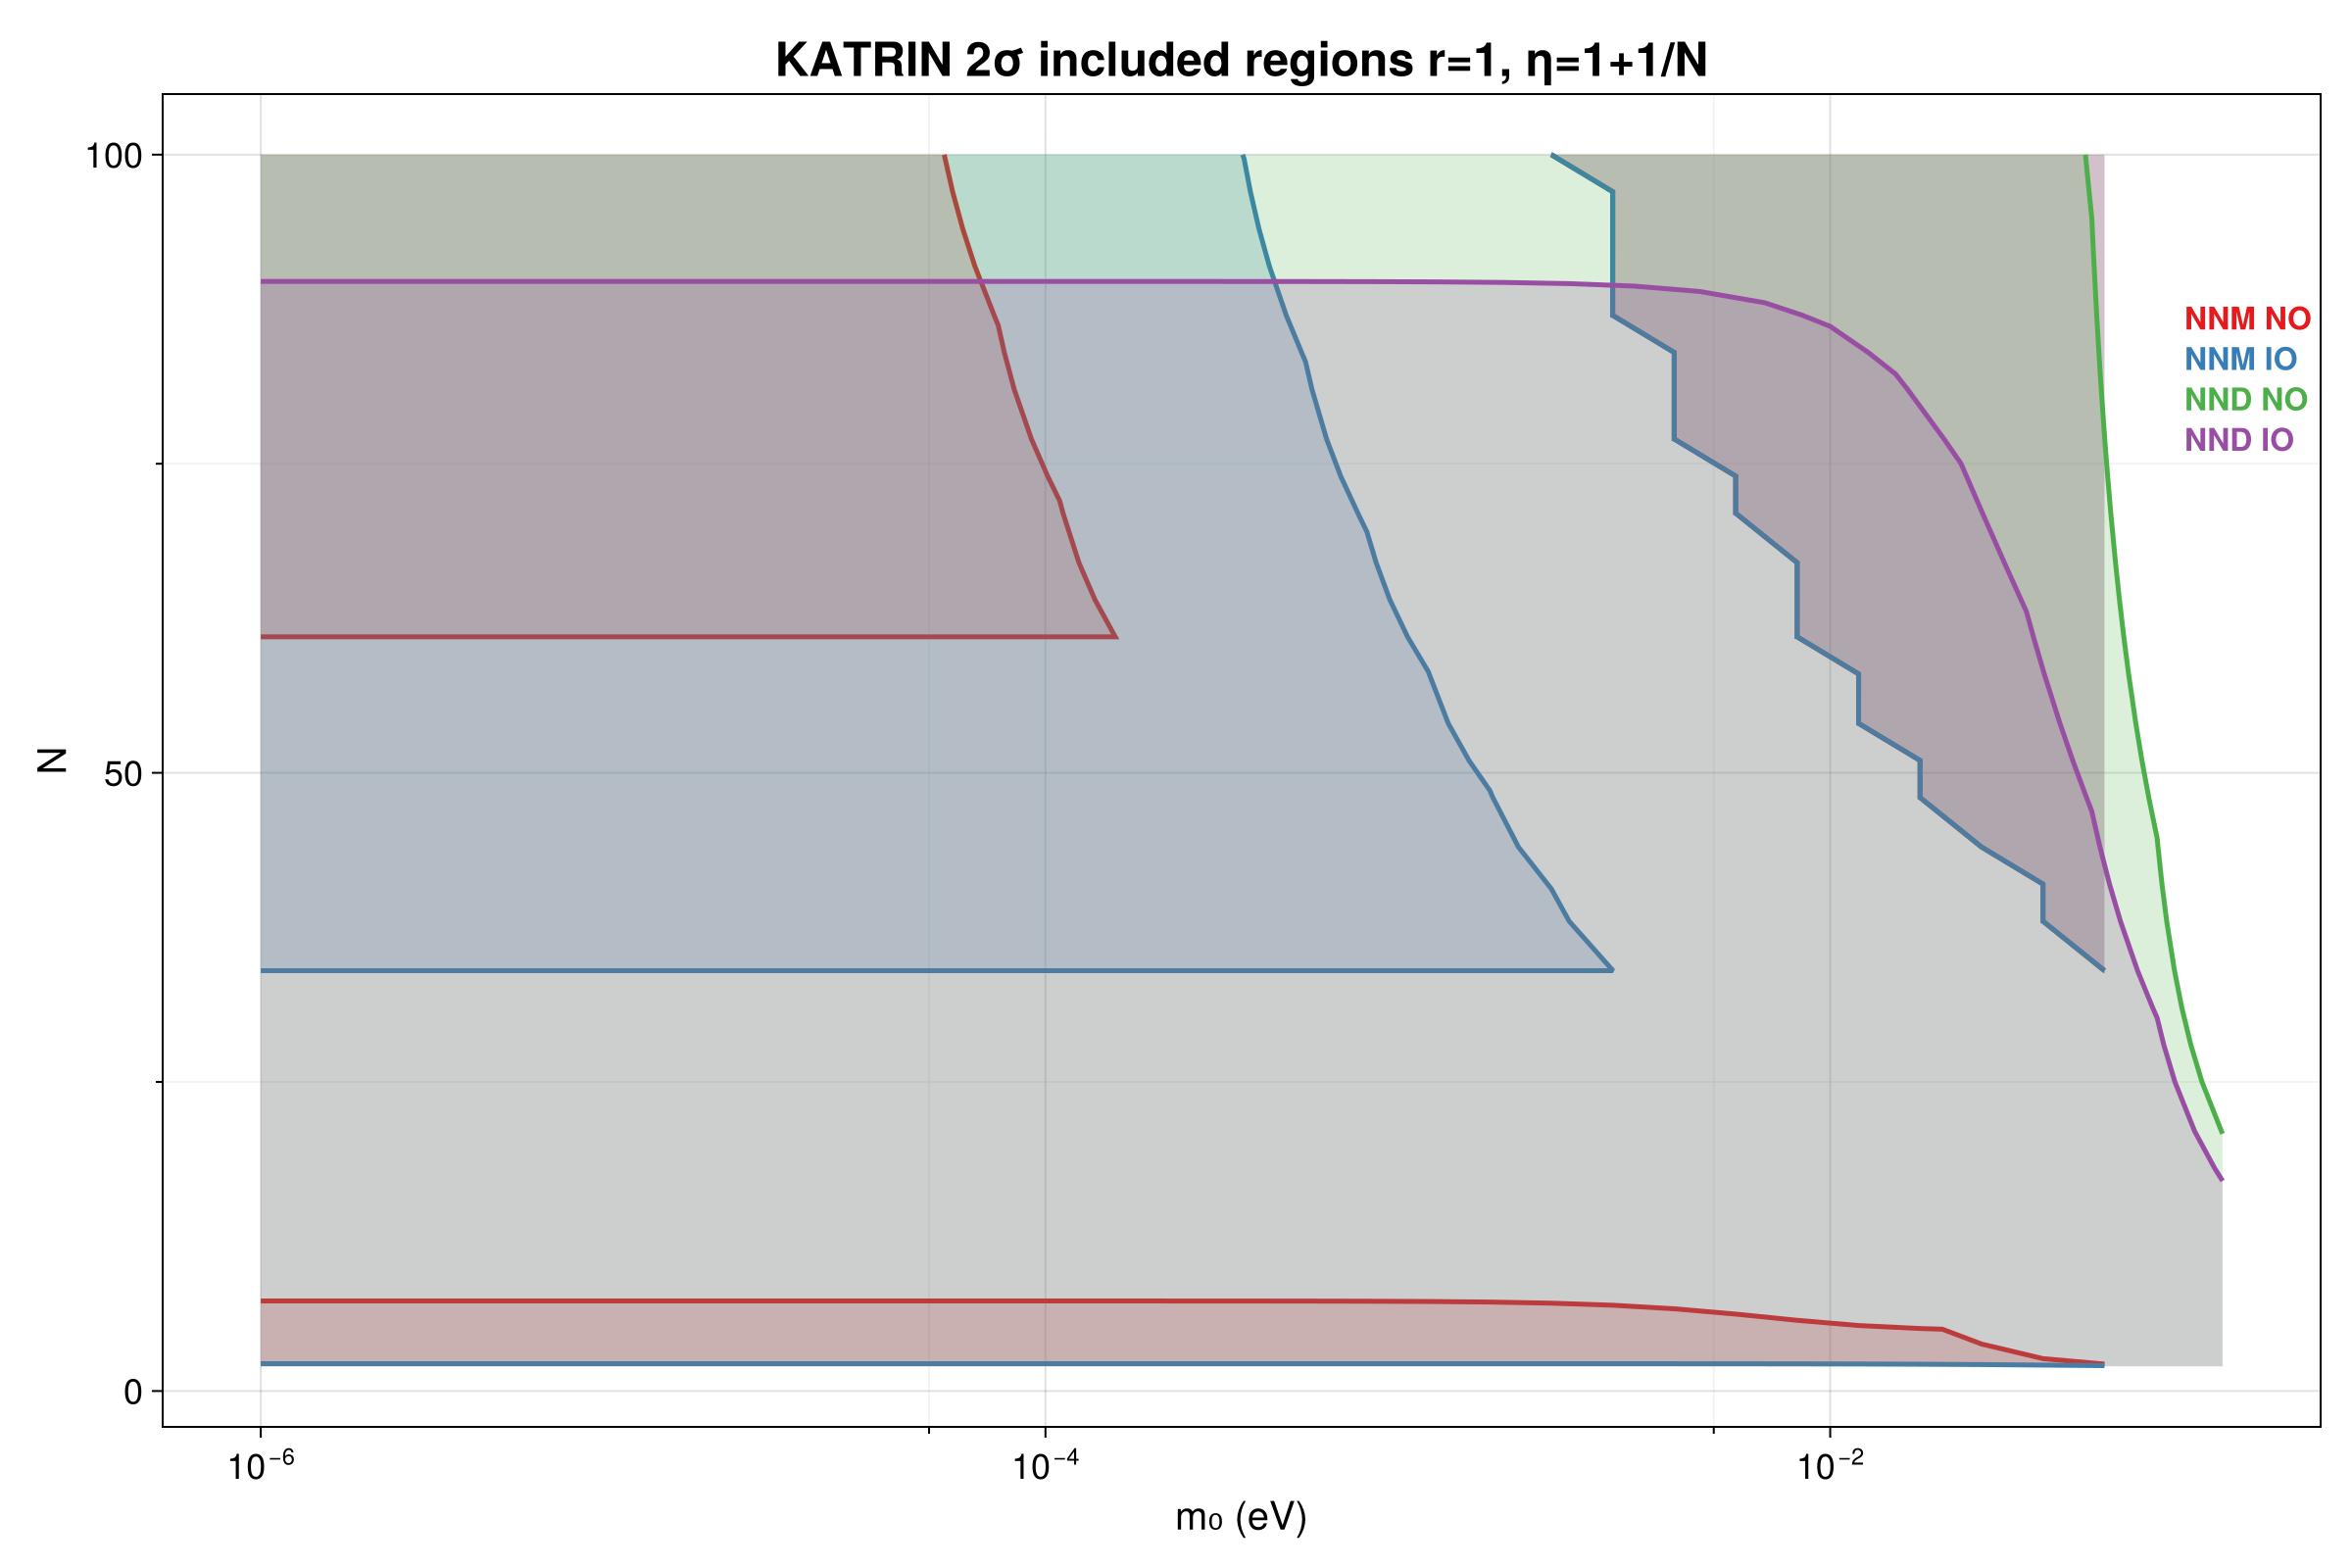

In [123]:
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    
    # Calculate 2σ level
    sigma_2_level = quantile(Chisq(2), 1 - 2*ccdf(Normal(), 2))
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) *" (eV)" , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    
    # Plot contours
    for (idx, result) in enumerate(results)
        dLLH = 2 * (maximum(result.values.log_posterior) .- result.values.log_posterior)
        
        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]
        
        # Create transparent version of the color
        color_transparent = RGBA(color, 1)
        color_transparent_full = RGBA(color, 0.2)
        
        contourf!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [0, sigma_2_level],
            colormap = cgrad([color_transparent_full, color_transparent])) 
        
        # Overlay the contour line on top
        contour!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [sigma_2_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle)
    end
    
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.85, 0.75, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.8)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_m0N_r=1_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_m0N_r=1_η=1+1N_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_m0N_r=1_η=1+1N_NND_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_m0N_r=1_η=1+1N_NND_IO.jld2"]
                
fig = superpose_contours(file_paths;  
    title="KATRIN 2σ included regions r=1, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    )

display(fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/superposed_contours_katrin_m0N.png", fig)